In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

from preprocessing import create_new_features


/home/bober/Desktop/ml_projects/ml_churn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Analisys of Churn Dataset

In [2]:
df = pd.read_csv("../data/churn_dataset.csv")
print(df.shape)
df.head()

(10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.isna().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [4]:
print(df.dtypes)
print("-"*30)
print(df.nunique())

customer_id           int64
credit_score          int64
country                 str
gender                  str
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object
------------------------------
customer_id         10000
credit_score          460
country                 3
gender                  2
age                    70
tenure                 11
balance              6382
products_number         4
credit_card             2
active_member           2
estimated_salary     9999
churn                   2
dtype: int64


In [5]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Distribution of churn

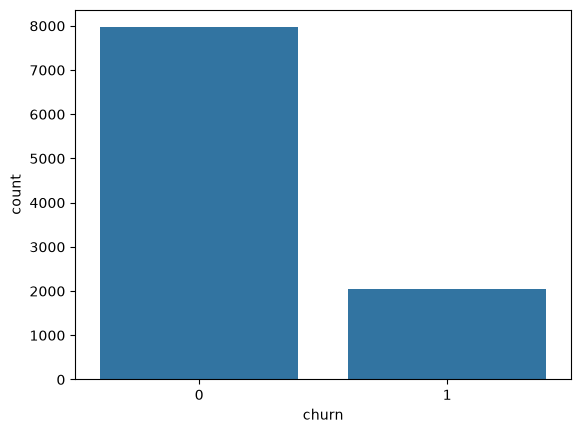

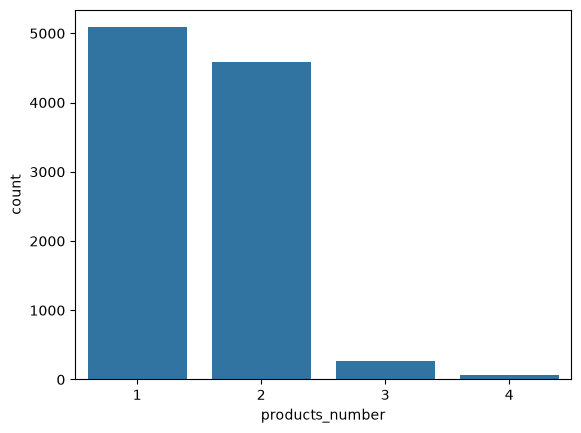

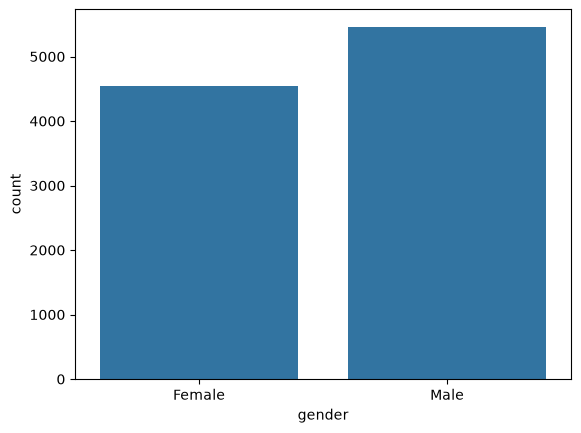

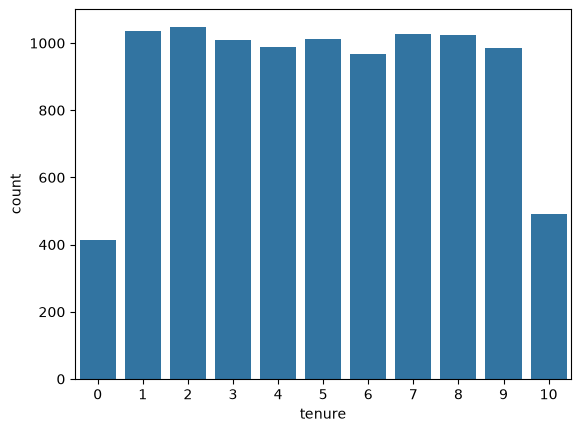

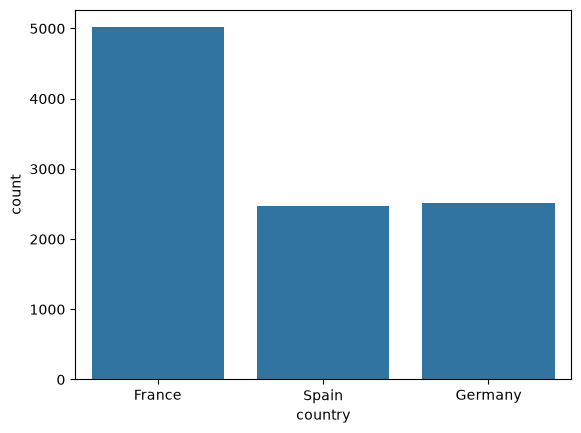

In [216]:
to_draw = ["churn", "products_number", "gender", "tenure", "country"]

for col in to_draw:
    sns.countplot(data=df,x=col)
    plt.show()

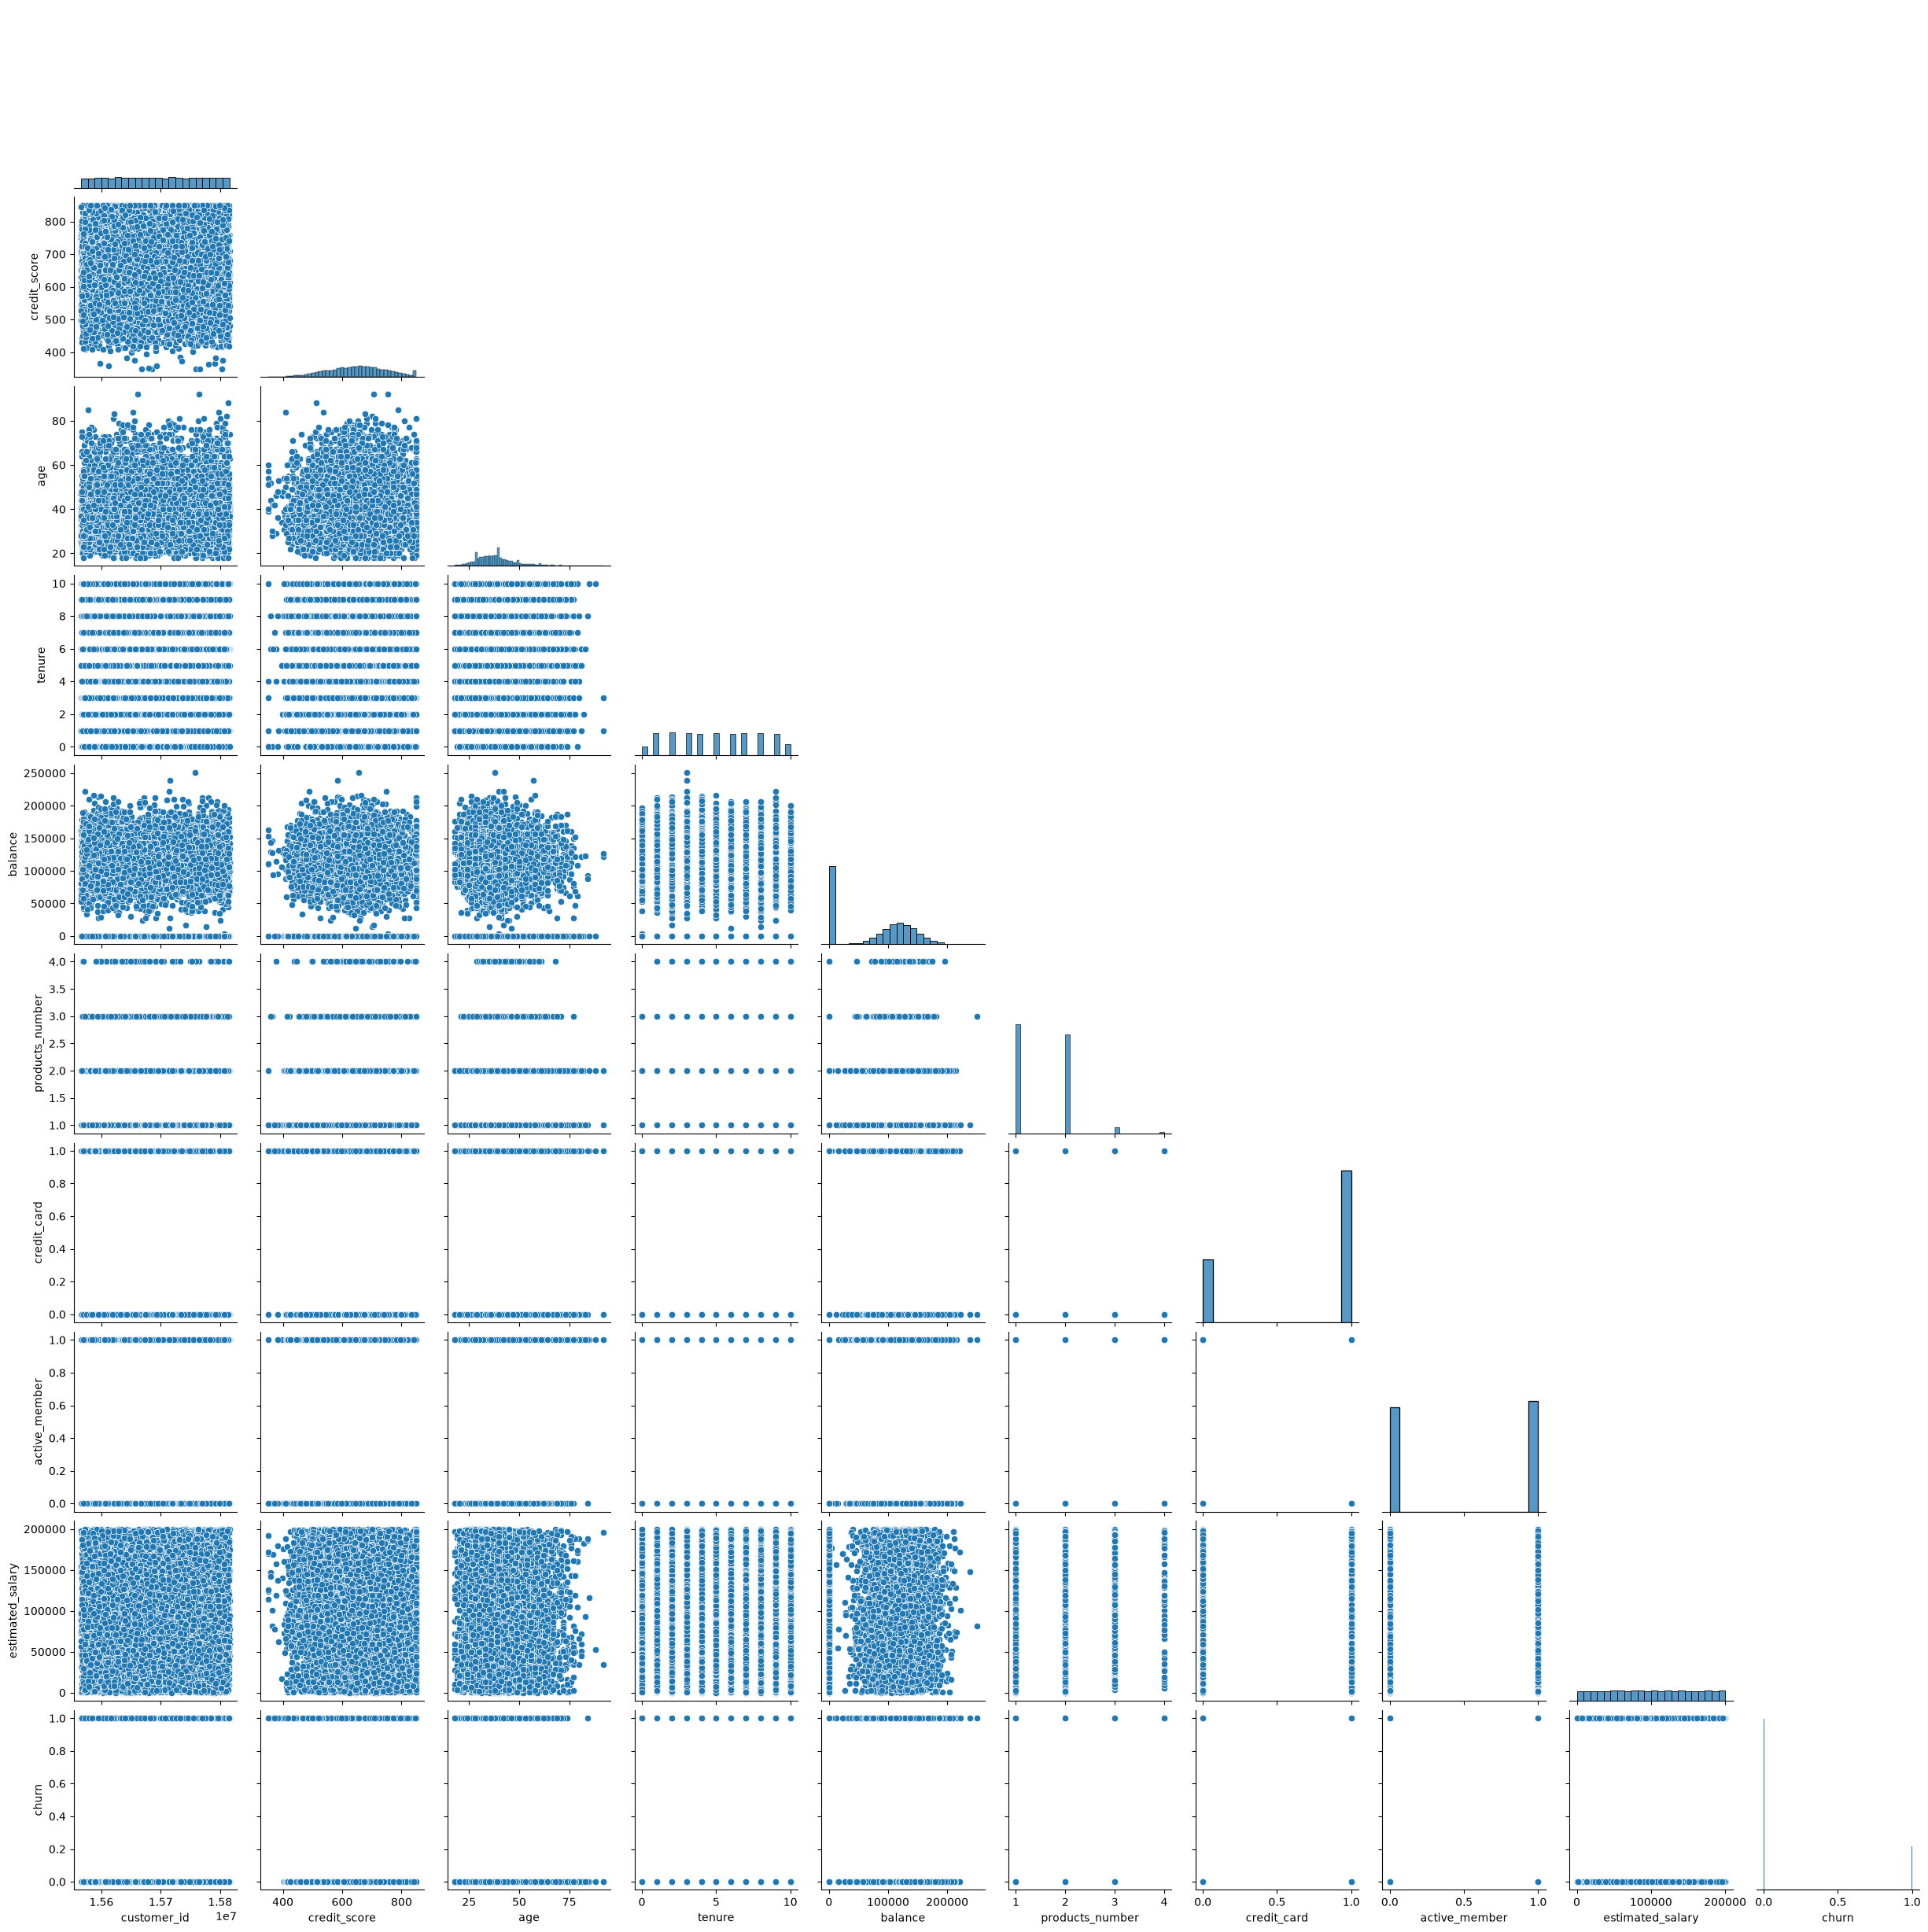

In [217]:
sns.pairplot(df, corner=True)
plt.show()

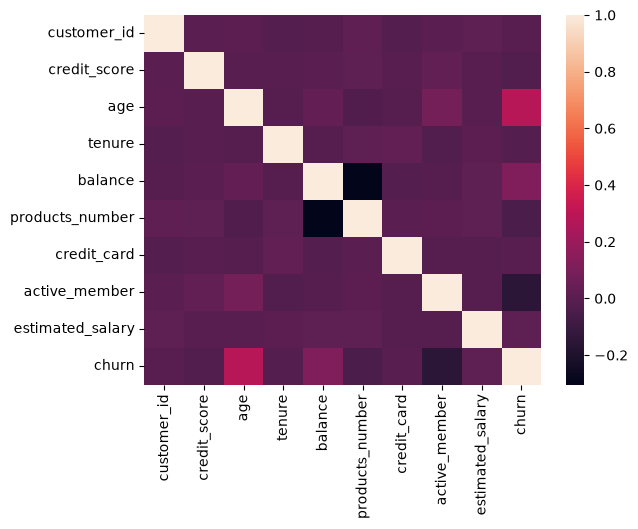

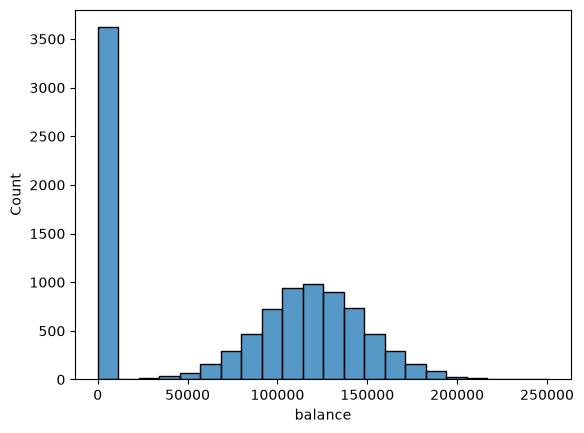

In [218]:
cols_to_corr = df.select_dtypes(include=["number"]).columns
sns.heatmap(df[cols_to_corr].corr())
plt.show()
sns.histplot(data=df,x="balance")
plt.show()

#### Dataset preprocessing

In [219]:
X = df.drop(columns=["churn","customer_id"])
y = df["churn"]

X_trainval, X_test, y_trainval, y_test = train_test_split(X,y, random_state=42,stratify=y,
                                                          test_size=0.3)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, random_state=42,
                                                  stratify=y_trainval,
                                                   test_size=0.2)


Future engineering

In [220]:
X_train = create_new_features(X_train)
X_test = create_new_features(X_test)
X_val = create_new_features(X_val)

In [221]:
X_full_train = pd.concat([X_train,X_val], ignore_index=True)
y_full_train = pd.concat([y_train,y_val], ignore_index=True)

In [222]:
explicit_cols = ["gender","country"]
numeric_cols = X_train.select_dtypes(include=["number"]).columns
cols_to_scale = [col for col in numeric_cols if X_train[col].nunique() > 2
                 and col not in explicit_cols]

transformer_tuning = ColumnTransformer(transformers=[
    ("gender", OrdinalEncoder(),["gender"]),
    ("country", OneHotEncoder(sparse_output=False),["country"]),
    ("std_scaling", StandardScaler(),cols_to_scale)
], remainder="passthrough")
transformer_tuning.set_output(transform="pandas")

transformer_final = ColumnTransformer(transformers=[
    ("gender", OrdinalEncoder(),["gender"]),
    ("country", OneHotEncoder(sparse_output=False),["country"]),
    ("std_scaling", StandardScaler(),cols_to_scale)
], remainder="passthrough")
transformer_final.set_output(transform="pandas")

X_full_train_transformed = transformer_final.fit_transform(X_full_train)
X_test_transformed = transformer_final.transform(X_test)

X_train = transformer_tuning.fit_transform(X_train)
X_val = transformer_tuning.transform(X_val)

X_full_train_transformed.columns = [col.split("__")[-1] for col in X_full_train_transformed.columns]
X_train.columns = [col.split("__")[-1] for col in X_train.columns]
X_test_transformed.columns = [col.split("__")[-1] for col in X_test_transformed.columns]
X_val.columns = [col.split("__")[-1] for col in X_val.columns]

### Fitting models

#### Logistic Regression

In [223]:
model = LogisticRegression(class_weight="balanced",random_state=42)

model.fit(X_full_train_transformed, y_full_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default

Metrics: F1-mera and ROC-AUC

In [224]:
def evaluate_model(model, x_test, y_test):
    y_pred = model.predict(x_test)
    y_pred_proba = model.predict_proba(x_test)[:,1]
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"F1-score: {f1}")
    print(f"ROC-AUC: {roc_auc}")

In [225]:
evaluate_model(model,X_test_transformed, y_test)

F1-score: 0.5181347150259067
ROC-AUC: 0.7918145016815341


In [226]:
def roc_curve_print(model, x_test, y_test):
    RocCurveDisplay.from_estimator(model, x_test, y_test)

    plt.plot([0,1],[0,1],color="navy",linestyle="--",label="Random guess (AUC = 0.5)")
    plt.title("ROC-curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid(True)

    plt.show()

#### SVM

In [227]:
model = SVC(kernel="rbf",probability=True, random_state=42, class_weight="balanced")

model.fit(X_full_train_transformed, y_full_train)

/home/bober/Desktop/ml_projects/ml_churn/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200


Metrics

In [228]:
evaluate_model(model,X_test_transformed, y_test)

F1-score: 0.6018041237113402
ROC-AUC: 0.8649148203132333


Random Forest

In [229]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced']),
        'random_state': 42,
        'n_jobs': -1
    }

    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    score = f1_score(y_val,y_pred)

    return score


sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=50)

[I 2026-07-23 01:20:37,236] A new study created in memory with name: no-name-44d842f3-d073-473b-9eff-e9ef6a53c51b
[I 2026-07-23 01:20:38,147] Trial 0 finished with value: 0.6051873198847262 and parameters: {'n_estimators': 150, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 6, 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.6051873198847262.
[I 2026-07-23 01:20:38,490] Trial 1 finished with value: 0.601123595505618 and parameters: {'n_estimators': 50, 'max_depth': 18, 'min_samples_split': 7, 'min_samples_leaf': 8, 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.6051873198847262.
[I 2026-07-23 01:20:40,055] Trial 2 finished with value: 0.5937921727395412 and parameters: {'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 3, 'min_samples_leaf': 2, 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.6051873198847262.
[I 2026-07-23 01:20:41,047] Trial 3 finished with value

In [230]:
rf = RandomForestClassifier(**study.best_params)
rf.fit(X_full_train_transformed, y_full_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first f

In [231]:
evaluate_model(rf,X_test_transformed, y_test)

F1-score: 0.6319272125723738
ROC-AUC: 0.8675952041510496


XGBoost

In [232]:
def objective(trial):
    ratio = float(np.sum(y_train == 0) / np.sum(y_train == 1))

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 700, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),

        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),

        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),

        'scale_pos_weight': trial.suggest_categorical('scale_pos_weight', [1.0, ratio]),

        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'logloss'
    }

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    score = f1_score(y_val, y_pred)

    return score

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=50)

[I 2026-07-23 01:21:49,708] A new study created in memory with name: no-name-98f28f6e-bd30-4afa-b505-c29a8c6e3ed9
[I 2026-07-23 01:21:55,559] Trial 0 finished with value: 0.5851979345955249 and parameters: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.08960785365368121, 'gamma': 0.0006155564318973012, 'reg_alpha': 2.5361081166471375e-07, 'reg_lambda': 2.5348407664333426e-07, 'subsample': 0.5290418060840998, 'colsample_bytree': 0.9330880728874675, 'scale_pos_weight': 3.9079754601226995}. Best is trial 0 with value: 0.5851979345955249.
[I 2026-07-23 01:21:56,560] Trial 1 finished with value: 0.6003976143141153 and parameters: {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.12106896936002161, 'gamma': 4.997040685255803e-07, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07, 'subsample': 0.6521211214797689, 'colsample_bytree': 0.762378215816119, 'scale_pos_weight': 1.0}. Best is trial 1 with value: 0.6003976143141153.
[I 2026-07-23 01:21:59,051] T

In [233]:
boost = XGBClassifier(**study.best_params)
boost.fit(X_full_train_transformed, y_full_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9614062991746116
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [234]:
evaluate_model(boost,X_test_transformed, y_test)

F1-score: 0.6253869969040248
ROC-AUC: 0.8639879041898938


In [235]:
study.best_params

{'n_estimators': 500,
 'max_depth': 7,
 'learning_rate': 0.019560953783334643,
 'gamma': 2.672621830271376e-07,
 'reg_alpha': 6.006928541035493e-08,
 'reg_lambda': 0.02973942966833018,
 'subsample': 0.6311734682623348,
 'colsample_bytree': 0.9614062991746116,
 'scale_pos_weight': 3.9079754601226995}

In [236]:
optuna.visualization.plot_optimization_history(study)

SHAP Analisys of Random Forest

In [237]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_transformed)

In [238]:
print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(3000, 14, 2)


In [239]:
shap_values_class1 = shap_values[:, :, 1]
print(shap_values_class1.shape)

(3000, 14)


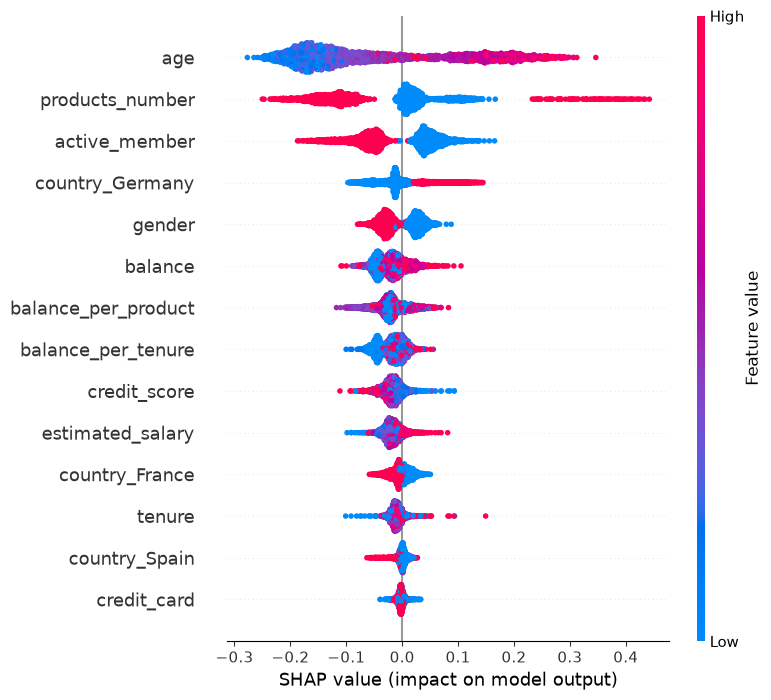

In [240]:
shap.summary_plot(shap_values_class1, X_test_transformed)

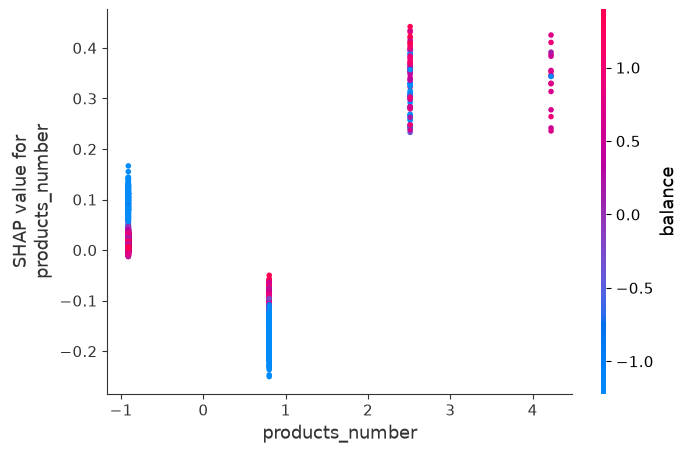

In [241]:
shap.dependence_plot("products_number", shap_values_class1, X_test_transformed)

Final Pipeline

In [242]:
full_pipeline = Pipeline([
    ("feature_engineering", FunctionTransformer(create_new_features)),
    ("preprocessing", transformer_final),
    ("model", rf)
])


full_pipeline.fit(X_full_train, y_full_train)
joblib.dump(full_pipeline, "model_pipeline.joblib")

['model_pipeline.joblib']

In [ ]:
loaded_pipeline = joblib.load("model_pipeline.joblib")
probas = loaded_pipeline.predict_proba(X_test)[:, 1]
preds = (probas >= 0.5).astype(int)

print("F1:", f1_score(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probas)) 

F1: 0.6311541565778854
ROC-AUC: 0.8686142638210181
